In [1]:
from google.colab import files
uploaded=files.upload()

Saving coffee.csv to coffee.csv


# Import Libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Load Dataset

In [3]:
df= pd.read_csv("coffee.csv")
df.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,Sales_amount
0,1,01-01-2023,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg,6.0
1,2,01-01-2023,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.2
2,3,01-01-2023,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg,9.0
3,4,01-01-2023,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm,2.0
4,5,01-01-2023,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.2


# Data Exploring

In [4]:
df.shape

(149116, 12)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149116 entries, 0 to 149115
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   transaction_id    149116 non-null  int64  
 1   transaction_date  149116 non-null  object 
 2   transaction_time  149116 non-null  object 
 3   transaction_qty   149116 non-null  int64  
 4   store_id          149116 non-null  int64  
 5   store_location    149116 non-null  object 
 6   product_id        149116 non-null  int64  
 7   unit_price        149116 non-null  float64
 8   product_category  149116 non-null  object 
 9   product_type      149116 non-null  object 
 10  product_detail    149116 non-null  object 
 11  Sales_amount      149116 non-null  float64
dtypes: float64(2), int64(4), object(6)
memory usage: 13.7+ MB


# Data Cleaning

In [6]:
df.isnull().sum()

,0
transaction_id,0
transaction_date,0
transaction_time,0
transaction_qty,0
store_id,0
store_location,0
product_id,0
unit_price,0
product_category,0
product_type,0


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
total_sales=df["Sales_amount"].sum().astype(int)
print(total_sales)

698812


In [9]:
average_sales=df["Sales_amount"].mean()
print(average_sales)

4.686367190643527


# Sales Analysis

1.**Overall Sales Performance**

I calculated the total revenue and average sales  value to understand the overall sales performance of the coffee shop.

In [10]:
product_revenue=df.groupby("product_category")["Sales_amount"].sum().sort_values(ascending=False)
print(product_revenue)

product_category
Coffee                269952.45
Tea                   196405.95
Bakery                 82315.64
Drinking Chocolate     72416.00
Coffee beans           40085.25
Branded                13607.00
Loose Tea              11213.60
Flavours                8408.80
Packaged Chocolate      4407.64
Name: Sales_amount, dtype: float64


In [11]:
quantity_sold=df.groupby("product_category")["transaction_qty"].sum().sort_values(ascending=False)
print(quantity_sold)

product_category
Coffee                89250
Tea                   69737
Bakery                23214
Drinking Chocolate    17457
Flavours              10511
Coffee beans           1828
Loose Tea              1210
Branded                 776
Packaged Chocolate      487
Name: transaction_qty, dtype: int64


# Product Analysis

2.**Product category and quantity performance**


I calculated the revenue from  each category of the products and also calculated how many products are sold in the each category

In [ ]:
highest_sold_products=df.groupby("product_type")["transaction_qty"].sum().sort_values(ascending=False).head(10)
print(highest_sold_products)

product_type
Brewed Chai tea          26250
Gourmet brewed coffee    25973
Barista Espresso         24943
Brewed Black tea         17462
Hot chocolate            17457
Brewed herbal tea        17328
Organic brewed coffee    13012
Drip coffee              12891
Premium brewed coffee    12431
Scone                    10465
Name: transaction_qty, dtype: int64


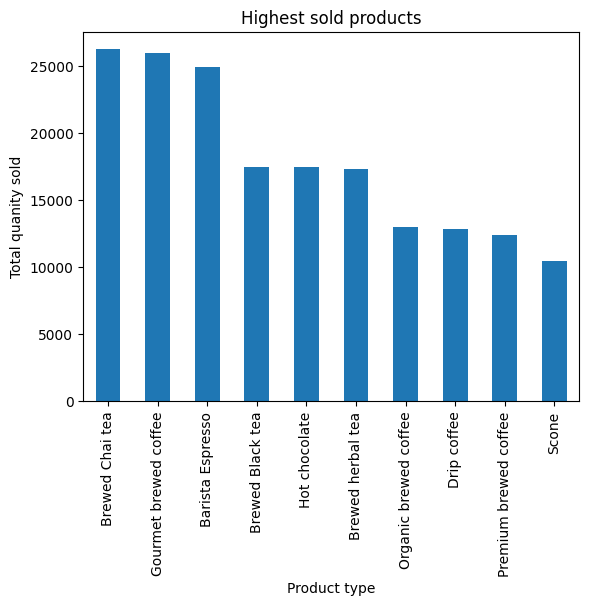

In [ ]:
highest_sold_products.plot(kind="bar")

plt.title("Highest sold products")
plt.xlabel("Product type")
plt.ylabel("Total quanity sold")
plt.show()

In [ ]:
highest_selling_products=df.groupby("product_type")["transaction_qty"].max().sort_values(ascending=False)
print(highest_selling_products)

product_type
Premium Beans            8
Housewares               6
Regular syrup            4
Sugar free syrup         4
Barista Espresso         4
Drip coffee              3
Hot chocolate            3
Gourmet brewed coffee    3
Organic brewed coffee    3
Brewed Chai tea          3
Brewed Black tea         3
Brewed herbal tea        3
Brewed Green tea         3
Scone                    3
Premium brewed coffee    3
Pastry                   2
Organic Beans            2
Biscotti                 2
Black tea                1
Chai tea                 1
Clothing                 1
Gourmet Beans            1
Espresso Beans           1
Drinking Chocolate       1
Herbal tea               1
House blend Beans        1
Green beans              1
Green tea                1
Organic Chocolate        1
Name: transaction_qty, dtype: int64


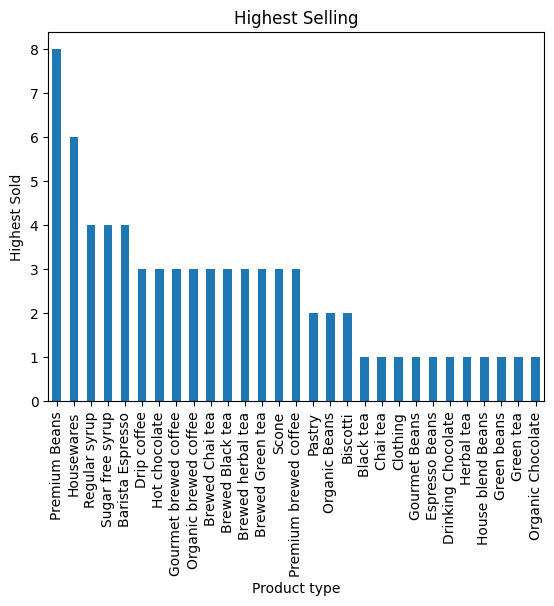

In [ ]:
highest_selling_products.plot(kind="bar")
plt.title("Highest Selling")
plt.xlabel("Product type")
plt.ylabel("Highest Sold")
plt.show()

In [ ]:
lowest_selling_products=df.groupby("product_type")["transaction_qty"].min().sort_values(ascending=False)
print(lowest_selling_products)

product_type
Barista Espresso         1
Biscotti                 1
Black tea                1
Brewed Black tea         1
Brewed Chai tea          1
Brewed Green tea         1
Brewed herbal tea        1
Chai tea                 1
Clothing                 1
Drinking Chocolate       1
Drip coffee              1
Espresso Beans           1
Gourmet Beans            1
Gourmet brewed coffee    1
Green beans              1
Green tea                1
Herbal tea               1
Hot chocolate            1
House blend Beans        1
Housewares               1
Organic Beans            1
Organic Chocolate        1
Organic brewed coffee    1
Pastry                   1
Premium Beans            1
Premium brewed coffee    1
Regular syrup            1
Scone                    1
Sugar free syrup         1
Name: transaction_qty, dtype: int64


# Product Selling Analysis

**3.Top_Selling Products**

I calculated top selling product of the coffee shop.My calculation of the coffee shope sales is shows  how many products are sold,maximum selling and minimum sellings.

In [ ]:
product_revenue=df.groupby("product_type")["Sales_amount"].sum().head(10).sort_values(ascending=False)
print(product_revenue)

product_type
Barista Espresso      91406.20
Brewed Chai tea       77081.95
Brewed Black tea      47932.00
Brewed herbal tea     47539.50
Brewed Green tea      23852.50
Biscotti              19793.53
Clothing               6163.00
Chai tea               4301.25
Drinking Chocolate     2728.04
Black tea              2711.85
Name: Sales_amount, dtype: float64


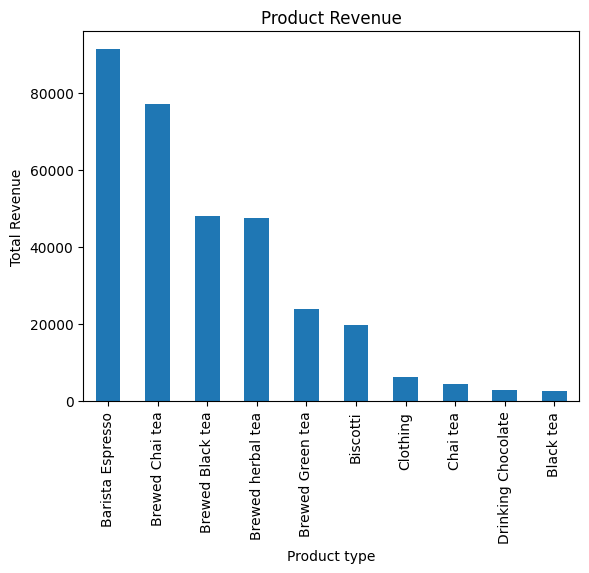

In [ ]:
product_revenue.plot(kind="bar")
plt.title("Product Revenue")
plt.xlabel("Product type")
plt.ylabel("Total Revenue")
plt.show()

In [ ]:
revenue_per_unit=(df.groupby("product_type")["Sales_amount"].sum()/df.groupby("product_type")["transaction_qty"].sum()).sort_values(ascending=False).head(1)
print(revenue_per_unit)

product_type
Premium Beans    35.919951
dtype: float64


In [ ]:
product_performance=df.groupby("product_category").agg(total_revenue=("Sales_amount","sum"),total_quantity=("transaction_qty","sum")).sort_values(by="total_revenue",ascending=False)
print(product_performance)

                    total_revenue  total_quantity
product_category                                 
Coffee                  269952.45           89250
Tea                     196405.95           69737
Bakery                   82315.64           23214
Drinking Chocolate       72416.00           17457
Coffee beans             40085.25            1828
Branded                  13607.00             776
Loose Tea                11213.60            1210
Flavours                  8408.80           10511
Packaged Chocolate        4407.64             487


**4.Top Products by Revenue**


The abouve the calcultion gives analysis of the coffee shop's product revenues

# Store Analysis

In [ ]:
highest_revenue_by_location=df.groupby("store_location")["Sales_amount"].sum().sort_values(ascending=False)
print(highest_revenue_by_location)

store_location
Hell's Kitchen     236511.17
Astoria            232243.91
Lower Manhattan    230057.25
Name: Sales_amount, dtype: float64


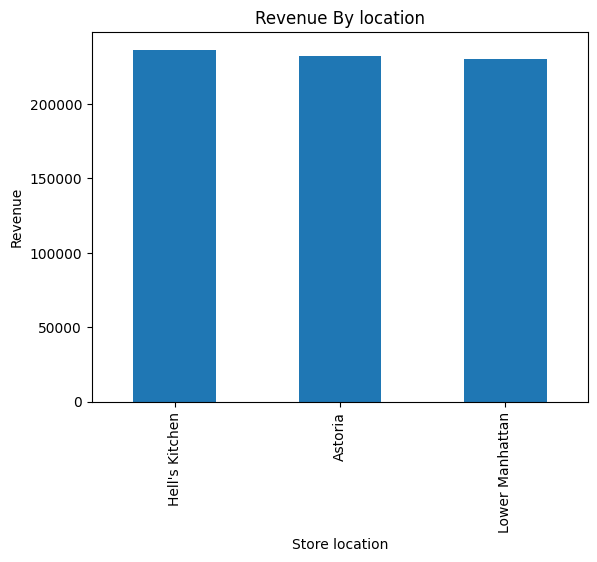

In [ ]:
highest_revenue_by_location.plot(kind="bar")
plt.title("Revenue By location")
plt.xlabel("Store location")
plt.ylabel("Revenue")
plt.show()


In [ ]:
heighest_sold_location=df.groupby("store_location")["transaction_qty"].nunique().sort_values(ascending=False)
print(heighest_sold_location)

store_location
Lower Manhattan    5
Hell's Kitchen     3
Astoria            2
Name: transaction_qty, dtype: int64


In [ ]:
highest_transaction=df.groupby("store_location")["transaction_id"].max().sort_values(ascending=False)
print(highest_transaction)

store_location
Hell's Kitchen     149456
Lower Manhattan    149451
Astoria            149449
Name: transaction_id, dtype: int64


In [ ]:
location_revenue=df.groupby("store_location")["Sales_amount"].sum().sort_values(ascending=False)
print(location_revenue)

store_location
Hell's Kitchen     236511.17
Astoria            232243.91
Lower Manhattan    230057.25
Name: Sales_amount, dtype: float64


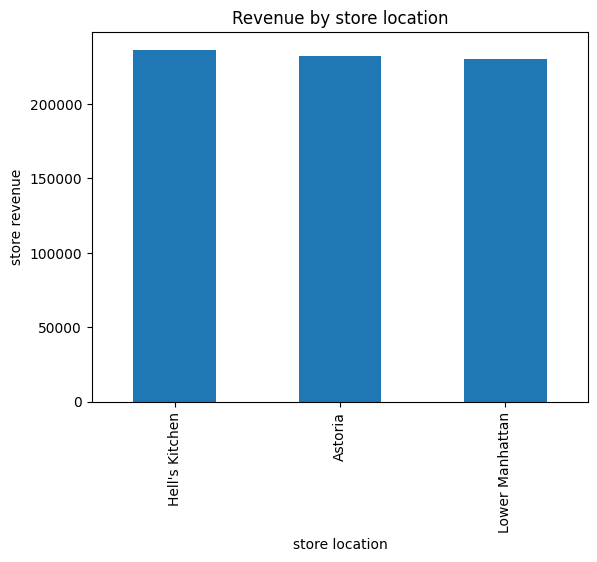

In [ ]:
location_revenue.sort_values(ascending=False).plot(kind="bar")
plt.title("Revenue by store location")
plt.xlabel("store location")
plt.ylabel("store revenue")
plt.show()

**5.Revenue By Store location**


I calculated sales and revenue by the each location of the coffee shop data.And also visualize the calculation.

# Time-Based Analysis

In [ ]:
df.groupby("transaction_date")["Sales_amount"].sum().sort_values(ascending=False)

,Sales_amount
transaction_date,
19-06-2023,6403.91
13-06-2023,6189.36
08-06-2023,6151.59
17-06-2023,6117.60
18-06-2023,6026.09
...,...
06-01-2023,2273.85
04-01-2023,2220.10
06-02-2023,2203.40


In [ ]:
daily_sales=df.groupby("transaction_date")["Sales_amount"].sum()
daily_sales[(daily_sales >=3500)&(daily_sales <=5000)].head(10)

,Sales_amount
transaction_date,
01-04-2023,3699.90
01-05-2023,4731.45
02-04-2023,3575.85
02-05-2023,4625.50
03-04-2023,3604.95
03-05-2023,4714.60
04-05-2023,4589.70
04-06-2023,4985.15
05-04-2023,3552.70


In [ ]:
daily_sellings=df.groupby("transaction_date")["transaction_qty"].sum().sort_values(ascending=False).head(10)
print(daily_sellings)

transaction_date
27-06-2023    1962
13-06-2023    1938
19-06-2023    1858
24-06-2023    1846
26-06-2023    1837
16-06-2023    1824
27-05-2023    1815
25-06-2023    1802
23-06-2023    1795
08-06-2023    1788
Name: transaction_qty, dtype: int64


In [ ]:
lowest_revenue_by_date=df.groupby("transaction_date")["Sales_amount"].idxmin().sort_values(ascending=True).head()
print(lowest_revenue_by_date)

transaction_date
01-01-2023       3
02-01-2023     589
03-01-2023    1171
04-01-2023    1698
05-01-2023    2242
Name: Sales_amount, dtype: int64


In [ ]:
df["transaction_date"]=pd.to_datetime(df["transaction_date"],dayfirst=True)
df["day"]=df["transaction_date"].dt.day_name()
df[["transaction_date","day"]]

daily_sales=df.groupby("day")["Sales_amount"].sum().sort_values(ascending=False)
print(daily_sales)

day
Monday       101677.28
Friday       101373.00
Thursday     100767.78
Wednesday    100313.54
Tuesday       99455.94
Sunday        98330.31
Saturday      96894.48
Name: Sales_amount, dtype: float64


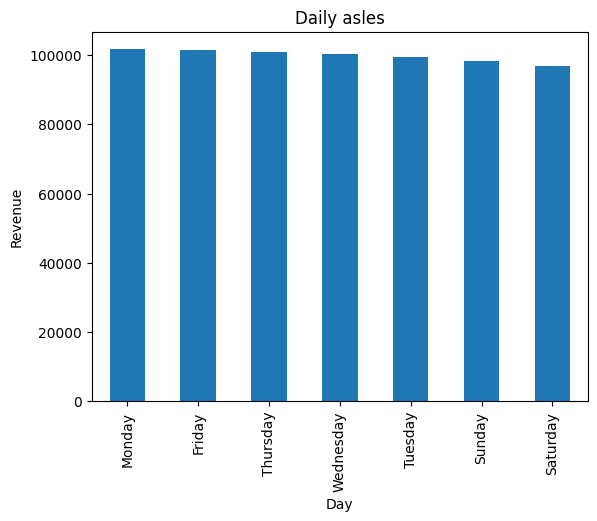

In [ ]:
daily_sales.plot(kind="bar")
plt.title("Daily asles")
plt.xlabel("Day")
plt.ylabel("Revenue")
plt.show()

In [ ]:
df.head()


,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,Sales_amount,day
0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg,6.0,Sunday
1,2,2023-01-01,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.2,Sunday
2,3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg,9.0,Sunday
3,4,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm,2.0,Sunday
4,5,2023-01-01,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.2,Sunday


In [ ]:
df["month"]=df["transaction_date"].dt.month_name()
df[["transaction_date","month"]]

,transaction_date,month
0,2023-01-01,January
1,2023-01-01,January
2,2023-01-01,January
3,2023-01-01,January
4,2023-01-01,January
...,...,...
149111,2023-06-30,June
149112,2023-06-30,June
149113,2023-06-30,June
149114,2023-06-30,June


In [ ]:
monthly_sales=df.groupby("month")["Sales_amount"].sum().sort_values(ascending=False)
print(monthly_sales)

month
June        166485.88
May         156727.76
April       118941.08
March        98834.68
January      81677.74
February     76145.19
Name: Sales_amount, dtype: float64


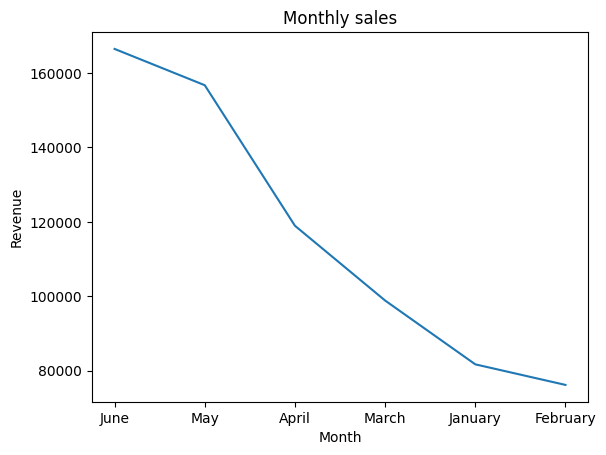

In [ ]:
monthly_sales.plot(kind="line")
plt.title("Monthly sales")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

In [ ]:
df["transaction_time"]=pd.to_datetime(df["transaction_time"],format="%H:%M:%S")
df["hour"]=df["transaction_time"].dt.hour

hourly_sales=df.groupby("hour")["Sales_amount"].sum().sort_values(ascending=False)
print(hourly_sales)

hour
10    88673.39
9     85169.53
8     82699.87
7     63526.47
11    46319.14
15    41733.10
14    41304.74
16    41122.75
13    40367.45
12    40192.79
17    40134.31
18    34286.20
19    28446.68
6     21900.27
20     2935.64
Name: Sales_amount, dtype: float64


**6.Revenue by Time,Hour,month,day,date**

I calculated the revenue by time,date,day,month,hour of the coffee shop sales

# Key Insights :

-Identified the overall sales performance of the coffee shop.

-Analyzed revenue by day,date,month and hour.

-Identified the best performing product and categories.

-Comepared  sales performance across the differnt time period.

-Used visulization to understand sales trends.


# **Conclusion**

# Coffee Shop Sales Analysis

**Project Overview**:

This project analyzes coffee shop sales data to understand sales performance ,costomer purchasing patterns and product performance.

**Tools used**:

Python

Pandas

Matplotlib

Google colab


